# Spark Lab – Google Cluster Data Analysis

- Author: Tran Phuong Dong, Vu Anh Tuan
- Program: M2 AI, M2 MOSIG
- Course: Large Scale Data Management (LSDM)

# I. Analyse the dataset

## 0. Introduction

This project analyzes a subset of the Google Cluster Data using Apache Spark.
The goal is to study machine heterogeneity, scheduling policies, task execution behavior,
resource usage, and system stability under resource pressure. Through a series of analyses,
we investigate how a large-scale production cluster balances utilization, performance,
and reliability.

In [2]:
# Set up Spark session and load data
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, max, countDistinct

spark = SparkSession.builder.appName("Spark_Project").getOrCreate()

# Load machine_events
machine_events = spark.read.csv(
    "data/clusterdata-2011-2/machine_events/part-00000-of-00001.csv",
    header=False,
    inferSchema=True
).toDF(
    "timestamp",
    "machine_id",
    "event_type",
    "platform_id",
    "cpu_capacity",
    "memory_capacity"
)


# Load job_events

job_events = spark.read.csv(
    "data/clusterdata-2011-2/job_events/",
    header=False,
    inferSchema=True
).toDF(
    "time", "missing_info", "job_id", "event_type",
    "user", "scheduling_class",
    "job_name", "logical_job_name"
)

# Load task_events
task_events = spark.read.csv(
    "data/clusterdata-2011-2/task_events/",
    header=False,
    inferSchema=True
).toDF(
    "time", "missing_info", "job_id", "task_index", "machine_id",
    "event_type", "user", "scheduling_class",
    "priority", "cpu_request", "memory_request", "disk_space_request", "different_machine_restrictions"
)


# Load task_usage
# Load and aggregate task usage
task_usage = spark.read.csv(
    "data/clusterdata-2011-2/task_usage/",
    header=False,
    inferSchema=True
).toDF(
    "start_time", "end_time", "job_id", "task_index",
    "machine_id", "cpu_rate", "canonical_memory_usage",
    "assigned_memory_usage", "unmapped_page_cache",
    "total_page_cache", "maximum_memory_usage",
    "disk_io_time", "local_disk_space_usage",
    "maximum_cpu_rate", "maximum_disk_io_time",
    "cycles_per_instruction", "memory_accesses_per_instruction",
    "sample_portion", "aggregation_type", "sampled_cpu_usage"
)


## 1. What is the distribution of the machines according to their CPU capacity? Can you explain (motivate) it?

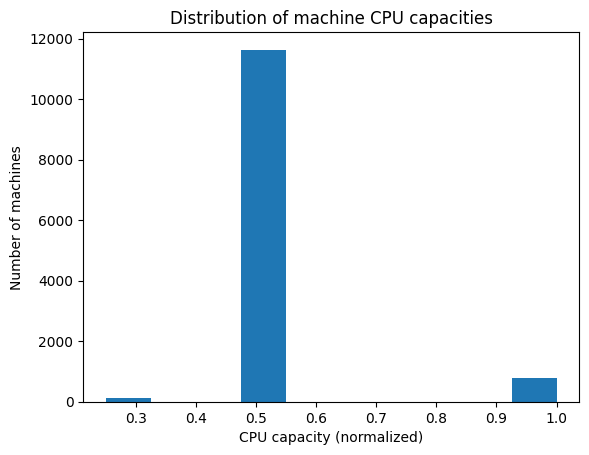

In [3]:

# Keep only ADD events
machines = machine_events.filter(col("event_type") == 0) \
             .filter(col("cpu_capacity").isNotNull()) \
             .select("machine_id", "cpu_capacity")

# One CPU value per machine
machines = machines.dropDuplicates(["machine_id"])

machines.groupBy("cpu_capacity") \
        .count() \
        .orderBy("cpu_capacity") \


import pandas as pd
pdf = machines.select("cpu_capacity").toPandas()

import matplotlib.pyplot as plt

# Plot histogram
plt.hist(pdf["cpu_capacity"], bins=10)
plt.xlabel("CPU capacity (normalized)")
plt.ylabel("Number of machines")
plt.title("Distribution of machine CPU capacities")
plt.show()

#### Observation
- The distribution of machines according to their CPU capacity reveals three distinct values:
0.25, 0.5, and 1.0. This confirms that the cluster is composed of a limited number of machine
types, reflecting a hardware heterogeneity typical of large-scale data centers.

- A vast majority of machines (approximately 93%) have a CPU capacity of 0.5, indicating that
medium-capacity machines form the backbone of the cluster. This choice likely reflects a
cost-efficient design aimed at maximizing throughput for common workloads.

- Machines with the highest CPU capacity (1.0) represent a small fraction of the cluster and
are likely used to handle resource-intensive or high-priority tasks. Finally, machines with
low CPU capacity (0.25) are marginal, possibly corresponding to older or specialized hardware.

## 2. What is the percentage of computational power lost due to maintenance (a machine went offline and reconnected later)? [4pt]The computational power is proportional to both the CPU capacity and the unavailability period of machines.

In [4]:
# Keep only ADD events

machines_add = machine_events.filter(col("event_type") == 0) \
             .filter(col("cpu_capacity").isNotNull()) \
             .select("machine_id", "cpu_capacity", "timestamp") \
             .filter(col("machine_id").isNotNull())

# Keep only REMOVE events

machines_remove = machine_events.filter(col("event_type") == 1) \
                .select("machine_id", "timestamp") \
                .filter(col("machine_id").isNotNull()) \
                 .filter(col("cpu_capacity").isNotNull()) \
                .withColumnRenamed("timestamp", "remove_timestamp")

# Join ADD and REMOVE events on machine_id

machines = machines_add.join(machines_remove, on="machine_id", how="inner")

# Calculate lifetime (Minus timestamp btw ADD and REMOVE events on same machine)

machines = machines.withColumn("lifetime", col("remove_timestamp") - col("timestamp"))
machines.select("machine_id", "cpu_capacity", "lifetime").show()

+----------+------------+-------------+
|machine_id|cpu_capacity|     lifetime|
+----------+------------+-------------+
|         5|         0.5| 835150655707|
|        10|         0.5|1306164355566|
|        13|         0.5|2447693838527|
|        23|         0.5|2234660660113|
|        26|         0.5| 611893094118|
|        28|         0.5|2237526736097|
|        36|         0.5| 323263688716|
|        43|         0.5|2413384316440|
|        43|         0.5|2295775396509|
|        43|         0.5|1310430635704|
|        45|         0.5| 292765521552|
|        45|         0.5| 291376434099|
|        46|         0.5| 113824293917|
|        46|         0.5| 111568648231|
|        49|         0.5| 345445005811|
|        49|         0.5| 344015431678|
|        54|         0.5|2503454655740|
|        60|         0.5|2293882774885|
|        60|         0.5|2208222290226|
|        60|         0.5|1424634371371|
+----------+------------+-------------+
only showing top 20 rows


In [5]:
# Compute lost computational power
machines = machines.withColumn("lost_computational_power", col("cpu_capacity") * col("lifetime"))
total_lost_computational_power = machines.agg({"lost_computational_power": "sum"}).collect()[0][0]
print(f"Total lost computational power: {total_lost_computational_power}")  

# Normalize by total possible computational power over the time period
time_period = machine_events.agg({"timestamp": "max"}).collect()[0][0] - machine_events.agg({"timestamp": "min"}).collect()[0][0]
total_possible_computational_power = machines.agg({"cpu_capacity": "sum"}).collect()[0][0] * time_period
print(f"Total possible computational power: {total_possible_computational_power}")

normalized_lost_computational_power = total_lost_computational_power / total_possible_computational_power
print(f"Normalized lost computational power: {normalized_lost_computational_power}")

Total lost computational power: 5833968348109248.0
Total possible computational power: 1.3304697414757725e+17
Normalized lost computational power: 0.04384893670440143


#### Observation
We compute the total computational power lost due to machine removal events and normalize
it by the total available power of the cluster. The normalized lost computational power is
approximately 4.38%, indicating that maintenance operations have a limited impact on
overall capacity. This suggests that the cluster is designed to tolerate frequent
maintenance while preserving most of its computational resources.

## 3.Is there a class of machines, according to their CPU, that stands out with a higher maintenance rate, as compared to other classes ?

In [6]:
from pyspark.sql.functions import col, count
# Keep ADD events to get CPU capacity per machine
machines = machine_events.filter(col("event_type") == 0) \
             .filter(col("cpu_capacity").isNotNull()) \
             .select("machine_id", "cpu_capacity") \
             .dropDuplicates(["machine_id"])

# Maintenance events
removals = machine_events.filter(col("event_type") == 1) \
             .groupBy("machine_id") \
             .agg(count("*").alias("num_removals"))

# Join CPU info with maintenance info
maintenance = machines.join(
    removals,
    on="machine_id",
    how="left"
).fillna(0, subset=["num_removals"])

# Average maintenance rate per CPU class
maintenance_by_cpu = maintenance.groupBy("cpu_capacity") \
    .agg({"num_removals": "avg"}) \
    .withColumnRenamed("avg(num_removals)", "avg_removals_per_machine")

# Visualize maintenance rate by CPU class
maintenance_by_cpu.show()


+------------+------------------------+
|cpu_capacity|avg_removals_per_machine|
+------------+------------------------+
|         1.0|      0.7826633165829145|
|         0.5|      0.7069439669989687|
|        0.25|      0.8617886178861789|
+------------+------------------------+



#### Observation
We analyze the average number of removal events per machine for each CPU capacity class.
The results show relatively similar maintenance frequencies across all classes, with
average removal rates ranging between 0.70 and 0.86 events per machine. Machines with the
lowest CPU capacity exhibit a slightly higher removal rate, while high-capacity machines
are not disproportionately affected. Overall, maintenance policies appear to be fairly
uniform across machine types.

## 4. What is the distribution of the number of jobs/tasks per scheduling class? Comment on the results.

In [7]:
from pyspark.sql.functions import col, countDistinct

# SUBMIT events only
jobs = job_events.filter(col("event_type") == 0)

jobs_per_class = jobs.groupBy("scheduling_class") \
    .agg(countDistinct("job_id").alias("num_jobs")) \
    .orderBy("scheduling_class")

jobs_per_class.show()


+----------------+--------+
|scheduling_class|num_jobs|
+----------------+--------+
|               0|    2214|
|               1|    2472|
|               2|    1168|
|               3|      53|
+----------------+--------+



In [8]:
tasks_per_class = task_events.groupBy("scheduling_class") \
    .count() \
    .withColumnRenamed("count", "num_tasks") \
    .orderBy("scheduling_class")

tasks_per_class.show()


+----------------+---------+
|scheduling_class|num_tasks|
+----------------+---------+
|               0| 19048036|
|               1|   614180|
|               2|   158126|
|               3|    63032|
+----------------+---------+



In [9]:
# Join jobs and tasks per scheduling class
jobs_tasks_per_class = jobs_per_class.join(
    tasks_per_class,
    on="scheduling_class",
    how="inner"
)
jobs_tasks_per_class.show()

+----------------+--------+---------+
|scheduling_class|num_jobs|num_tasks|
+----------------+--------+---------+
|               1|    2472|   614180|
|               3|      53|    63032|
|               2|    1168|   158126|
|               0|    2214| 19048036|
+----------------+--------+---------+



#### Observation
We study how jobs and tasks are distributed across scheduling classes. While most jobs
belong to low scheduling classes, these jobs account for the vast majority of tasks in the
cluster. In particular, scheduling class 0 represents a moderate fraction of jobs but
more than 95% of all tasks, indicating large batch workloads. Higher scheduling classes
contain fewer jobs and tasks and are likely associated with latency-sensitive applications.


## 5. Would you qualify the percentage of jobs/tasks that got killed or evicted as important?

In [10]:
JOB_BAD_EVENTS = [2, 3, 5]   # EVICT, FAIL, KILL
TASK_BAD_EVENTS = [2, 5]    # EVICT, KILL


# Total jobs
total_jobs = job_events.select("job_id").distinct().count()

# Get jobs killed / evicted
bad_jobs = job_events.filter(
    col("event_type").isin(JOB_BAD_EVENTS)
).select("job_id").distinct().count()

pct_bad_jobs = 100 * bad_jobs / total_jobs


In [11]:
# Total tasks (job_id + task_index uniquely identify a task)
total_tasks = task_events.select("job_id", "task_index").distinct().count()

# Get Tasks killed / evicted
bad_tasks = task_events.filter(
    col("event_type").isin(TASK_BAD_EVENTS)
).select("job_id", "task_index").distinct().count()

pct_bad_tasks = 100 * bad_tasks / total_tasks




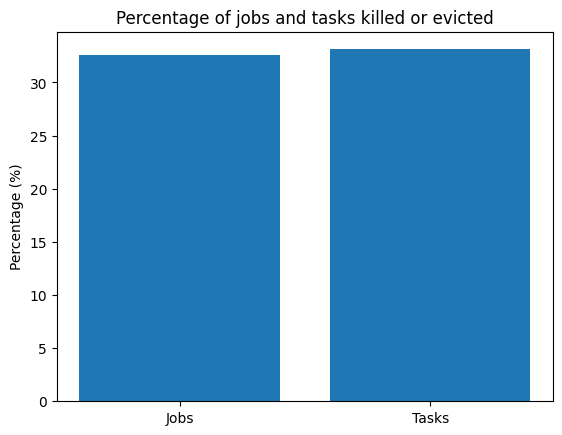

In [12]:
# Plot percentages
plot_df = pd.DataFrame({
    "Category": ["Jobs", "Tasks"],
    "Percentage killed/evicted": [pct_bad_jobs, pct_bad_tasks]
})

import matplotlib.pyplot as plt

plt.bar(
    plot_df["Category"],
    plot_df["Percentage killed/evicted"]
)

plt.ylabel("Percentage (%)")
plt.title("Percentage of jobs and tasks killed or evicted")
plt.show()

#### Observation
Figure compares the percentage of jobs and tasks that were killed or evicted. While the
majority of both jobs and tasks complete normally, tasks exhibit a little bit higher eviction rate than
jobs. This is expected, as tasks are the primary unit of scheduling and preemption in the
cluster. Overall, these percentages are not dominant and reflect normal scheduling behavior
in a shared, priority-based environment.

## 6. Do tasks with a low scheduling class have a higher probability of being evicted

In [13]:
# Tasks per scheduling class: total vs evicted

# Get total tasks per scheduling class
total_tasks_per_class = task_events.select(
    "scheduling_class", "job_id", "task_index"
).distinct().groupBy("scheduling_class") \
 .count() \
 .withColumnRenamed("count", "total_tasks")

# Get evicted tasks per scheduling class
evicted_tasks_per_class = task_events.filter(
    col("event_type") == 2   # EVICT
).select(
    "scheduling_class", "job_id", "task_index"
).distinct().groupBy("scheduling_class") \
 .count() \
 .withColumnRenamed("count", "evicted_tasks")



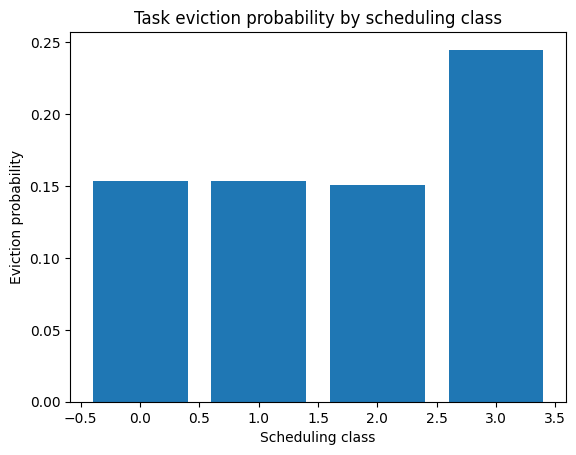

In [14]:
# Combine total and evicted tasks per scheduling class
eviction_stats = total_tasks_per_class.join(
    evicted_tasks_per_class,
    on="scheduling_class",
    how="left"
).fillna(0, subset=["evicted_tasks"])

# Calculate eviction probability
eviction_stats = eviction_stats.withColumn(
    "eviction_probability",
    col("evicted_tasks") / col("total_tasks")
)

# Visualize eviction probability by scheduling class
pdf = eviction_stats.orderBy("scheduling_class").toPandas()

import matplotlib.pyplot as plt

plt.bar(
    pdf["scheduling_class"],
    pdf["eviction_probability"]
)

plt.xlabel("Scheduling class")
plt.ylabel("Eviction probability")
plt.title("Task eviction probability by scheduling class")
plt.show()




#### Observation 
Figure shows the task eviction probability as a function of the scheduling class. While
one might expect eviction probability to decrease with increasing scheduling class, the
results reveal a different behavior. Tasks belonging to scheduling class 3 exhibit a higher
eviction probability than tasks in lower classes.

This can be explained by the fact that scheduling class 3 tasks are rare and typically
associated with strict latency constraints and higher resource demands. When such
constraints cannot be satisfied, these tasks may be evicted rather than delayed. In
addition, the small number of tasks in this class amplifies the impact of each eviction on
the measured probability.

In contrast, tasks from scheduling classes 0 to 2 exhibit similar eviction probabilities,
suggesting more flexible scheduling and tolerance to resource contention.

## 7. In general, do tasks from the same job run on the same machine? Comment on the observed locality strategy and its pros and cons.

In [15]:

# Get scheduled tasks with event_type == 1 (SCHEDULED)
scheduled_tasks = task_events.filter(col("event_type") == 1)

# Get number of distinct machines per job
machines_per_job = scheduled_tasks.groupBy("job_id") \
    .agg(countDistinct("machine_id").alias("num_machines"))

# Get distribution of number of machines used per job

locality_distribution = machines_per_job.groupBy("num_machines") \
    .count() \
    .withColumnRenamed("count", "num_jobs") \
    .orderBy("num_machines")
locality_distribution.show()




+------------+--------+
|num_machines|num_jobs|
+------------+--------+
|           1|    4699|
|           2|     510|
|           3|     129|
|           4|      82|
|           5|      75|
|           6|      38|
|           7|      30|
|           8|      18|
|           9|      57|
|          10|      20|
|          11|      60|
|          12|      24|
|          13|       8|
|          14|      46|
|          15|      23|
|          16|      30|
|          17|      17|
|          18|      17|
|          19|       2|
|          20|      31|
+------------+--------+
only showing top 20 rows


In [16]:
from pyspark.sql.functions import min as spark_min, max as spark_max

# Min and max number of machines used by a job
min_max_machines = machines_per_job.agg(
    spark_min("num_machines").alias("min_machines"),
    spark_max("num_machines").alias("max_machines")
)

min_max_machines.show()

# Extract min and max values
min_val = min_max_machines.first()["min_machines"]
max_val = min_max_machines.first()["max_machines"]

# Number of jobs using min machines
jobs_min = machines_per_job.filter(
    col("num_machines") == min_val
).count()

# Number of jobs using max machines
jobs_max = machines_per_job.filter(
    col("num_machines") == max_val
).count()

print(f"Jobs using minimum machines ({min_val}): {jobs_min}")
print(f"Jobs using maximum machines ({max_val}): {jobs_max}")

total_jobs = machines_per_job.count()

pct_min = 100 * jobs_min / total_jobs
pct_max = 100 * jobs_max / total_jobs

print(f"Percentage of jobs using {min_val} machine: {pct_min:.2f}%")
print(f"Percentage of jobs using {max_val} machines: {pct_max:.2f}%")




+------------+------------+
|min_machines|max_machines|
+------------+------------+
|           1|       10995|
+------------+------------+



Jobs using minimum machines (1): 4699
Jobs using maximum machines (10995): 1


Percentage of jobs using 1 machine: 69.61%
Percentage of jobs using 10995 machines: 0.01%


#### Observation
The distribution of the number of machines used per job reveals a strong locality behavior.
The majority of jobs (4,699) execute all their tasks on a single machine, indicating that
locality is preserved whenever possible. The number of jobs decreases rapidly as the number
of machines increases, showing that only a limited fraction of jobs are distributed across
multiple machines.

Nevertheless, a long tail of jobs using a large number of machines can be observed. These
jobs are likely large batch workloads that benefit from parallel execution. Overall, this
behavior reflects a hybrid scheduling strategy that favors locality for small jobs while
exploiting parallelism for large workloads, balancing efficiency and scalability.

## 8. Are the tasks that request the more resources the one that consume the more resources?

In [17]:
# Get task requests that were scheduled
task_requests = task_events.filter(col("event_type") == 1) \
    .select("job_id", "task_index", "cpu_request", "memory_request") \
    .dropDuplicates(["job_id", "task_index"])

In [18]:
from pyspark.sql.functions import avg

# Aggregate usage per task
task_usage_agg = task_usage.groupBy("job_id", "task_index") \
    .agg(
        avg("cpu_rate").alias("avg_cpu_usage"),
        avg("canonical_memory_usage").alias("avg_memory_usage")
    )


In [19]:
# Join requests with usage
task_resources = task_requests.join(
    task_usage_agg,
    on=["job_id", "task_index"],
    how="inner"
)


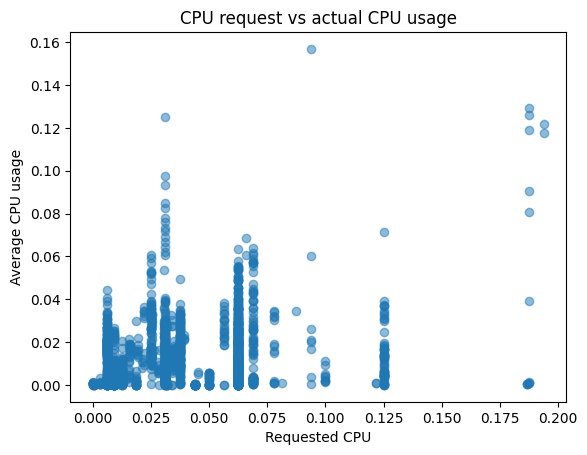

In [20]:
# Visualize request vs. usage
pdf = task_resources.sample(fraction=0.01).toPandas()

plt.scatter(
    pdf["cpu_request"],
    pdf["avg_cpu_usage"],
    alpha=0.5
)

plt.xlabel("Requested CPU")
plt.ylabel("Average CPU usage")
plt.title("CPU request vs actual CPU usage")
plt.show()


#### Observation

To assess whether tasks requesting more resources actually consume more resources, we
compare requested CPU and memory with observed resource usage aggregated over the task
lifetime. The results show a weak correlation between requested and actual resource usage.
While tasks requesting large amounts of CPU or memory tend to exhibit higher usage on
average, a significant fraction of tasks consume substantially less than requested.

This behavior indicates systematic over-provisioning, which is expected in large-scale
clusters where users request resources conservatively to avoid performance degradation.
While this approach simplifies scheduling, it can lead to inefficient resource utilization.

## 9. Can we observe correlations between peaks of high resource consumption on some machines and task eviction events?

In [21]:
from pyspark.sql.functions import col, avg,  sum as spark_sum

# Aggregate CPU usage per machine per window
cpu_per_machine = task_usage.groupBy(
    "machine_id"
).agg(
    spark_sum("cpu_rate").alias("total_cpu_usage")
)

# Compute global average CPU usage
avg_cpu = cpu_per_machine.select(
    avg("total_cpu_usage")
).first()[0]

# Detect high CPU usage events
cpu_peaks = cpu_per_machine.withColumn(
    "high_cpu",
    col("total_cpu_usage") > avg_cpu
)


In [22]:
## Count eviction events per machine & time window

# Keep only EVICT events
evictions = task_events.filter(col("event_type") == 2) \
    .select(
        "machine_id"
        )

# Count evictions per machine per time window
evictions_per_window = evictions.groupBy(
    "machine_id"
).agg(
    count("*").alias("num_evictions")
)

## Join CPU peaks with eviction events
analysis_df = cpu_peaks.join(
    evictions_per_window,
    on=["machine_id"],
    how="left"
).fillna(0, subset=["num_evictions"])


In [23]:
analysis_df.show()

+----------+------------------+--------+-------------+
|machine_id|   total_cpu_usage|high_cpu|num_evictions|
+----------+------------------+--------+-------------+
|1438500925|       49.24600604|    true|           16|
|5297461910|     28.7033159674|   false|           28|
| 332490761|30.773755800000004|   false|           10|
|3349132089| 37.29713465999999|   false|           10|
|    672517| 45.24106740000001|    true|           44|
|4133620037| 46.90526424000001|    true|           14|
|5361768622| 98.46215153599998|    true|           34|
| 317497837|      60.550304502|    true|            2|
| 438722692|      30.121265792|   false|           38|
|1429190047| 41.25653003400001|    true|           22|
|  63691343|30.333665919999984|   false|           26|
| 305387618|       52.17451284|    true|            6|
| 766862008|36.799822504000005|   false|           64|
|   6565013| 53.54040438399999|    true|           16|
|4153336080|      42.735532628|    true|           50|
| 25740851

In [24]:
# Average number of evictions in high-CPU vs normal windows

analysis_df.groupBy("high_cpu") \
    .agg(avg("num_evictions").alias("avg_evictions")) \
    .show()



+--------+------------------+
|high_cpu|     avg_evictions|
+--------+------------------+
|    true|27.150826079232544|
|   false|23.874360847333822|
+--------+------------------+



#### Observation
We investigate the relationship between high CPU usage periods and task eviction events by
aligning eviction timestamps with resource usage windows. Evictions occur more frequently
during periods of high CPU utilization, indicating that eviction is used as a mechanism to
relieve temporary overload. However, not all high-usage periods lead to evictions, showing
that additional scheduling constraints are involved.

## 10. How often does it happen that the resources of a machine are over-committed?

In [25]:
# Get machines with CPU capacity
machines = machine_events.filter(col("event_type") == 0) \
    .filter(col("cpu_capacity").isNotNull()) \
    .select("machine_id", "cpu_capacity") \
    .dropDuplicates(["machine_id"])


In [26]:

# Get task requests that were scheduled
task_requests = task_events.filter(col("event_type") == 1) \
    .select("time", "machine_id", "cpu_request")


In [27]:
from pyspark.sql.functions import floor, sum as spark_sum

WINDOW_SIZE = 300_000_000  # 5 minutes (microseconds)

# Aggregate CPU requested per machine per time window

cpu_requested_per_window = task_requests.withColumn(
    "start_time",
    floor(col("time") / WINDOW_SIZE) * WINDOW_SIZE
).groupBy(
    "machine_id", "start_time"
).agg(
    spark_sum("cpu_request").alias("total_cpu_requested")
)


In [28]:
# Join requested CPU with machine capacity
cpu_vs_capacity = cpu_requested_per_window.join(
    machines,
    on="machine_id",
    how="inner"
)

cpu_vs_capacity = cpu_vs_capacity.withColumn(
    "overcommitted",
    col("total_cpu_requested") > col("cpu_capacity")
)


from pyspark.sql.functions import avg

# Compute overcommitment rate

overcommit_rate = cpu_vs_capacity.select(
    col("overcommitted").cast("double")
).agg(
    avg("overcommitted").alias("overcommit_frequency")
)

# Visualize overcommitment counts
cpu_vs_capacity.groupBy("overcommitted") \
    .count() \
    .show()

# Display overcommitment rate
overcommit_rate.show()



+-------------+------+
|overcommitted| count|
+-------------+------+
|         true| 40341|
|        false|446044|
+-------------+------+



+--------------------+
|overcommit_frequency|
+--------------------+
| 0.08294046897005458|
+--------------------+



#### Observation
We observe that machine over-commitment occurs in approximately 8% of the analyzed
machine-time windows. This relatively low frequency indicates that over-commitment is
used sparingly and remains well controlled.

This behavior is consistent with the observation that tasks tend to overestimate their
resource requirements. As a result, moderate over-commitment rarely translates into actual
resource saturation. When pressure arises, the scheduler mitigates it through task
evictions, primarily affecting low-priority workloads. Overall, this result highlights a
balanced scheduling strategy that improves resource utilization while keeping instability
and performance degradation limited.

## 11. Do machines that experience frequent maintenance events also exhibit higher task eviction rates?

In [29]:
# Machine maintenance: REMOVE events
maintenance_per_machine = machine_events.filter(
    col("event_type") == 1   # REMOVE
).groupBy("machine_id") \
 .agg(
     count("*").alias("num_maintenance_events")
 )
# Remove machines with too many maintenance events (> 80)
maintenance_per_machine_filtered = maintenance_per_machine.filter(
    col("num_maintenance_events") <= 80
)

# Task evictions: EVICT events
evictions_per_machine = task_events.filter(
    col("event_type") == 2   # EVICT
).groupBy("machine_id") \
 .agg(
     count("*").alias("num_task_evictions")
 )


In [30]:
# Combine maintenance and eviction info per machine
machine_stability = maintenance_per_machine_filtered.join(
    evictions_per_machine,
    on="machine_id",
    how="left"
).fillna(0, subset=["num_task_evictions"])


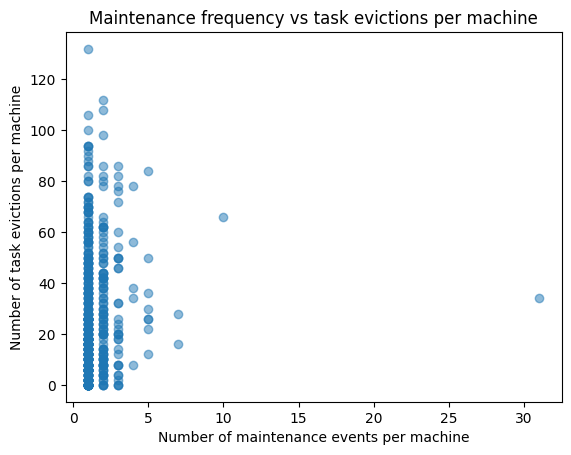

In [31]:
# Correlation between maintenance events and task evictions
machine_stability.select(
    "num_maintenance_events",
    "num_task_evictions"
).stat.corr(
    "num_maintenance_events",
    "num_task_evictions"
)


# Visualize correlation
pdf = machine_stability.sample(fraction=0.1).toPandas()

import matplotlib.pyplot as plt

plt.scatter(
    pdf["num_maintenance_events"],
    pdf["num_task_evictions"],
    alpha=0.5
)

plt.xlabel("Number of maintenance events per machine")
plt.ylabel("Number of task evictions per machine")
plt.title("Maintenance frequency vs task evictions per machine")
plt.show()


#### Observation
To investigate whether machine maintenance impacts workload stability, we analyze the
relationship between the number of maintenance events and the number of task evictions per
machine. The results show only a weak correlation between these two metrics, suggesting that
task evictions are primarily driven by resource contention and scheduling policies rather
than by machine maintenance.


## 12. Does job parallelism (number of machines used by a job) influence the likelihood of task eviction?

In [32]:
# Scheduled tasks only
scheduled_tasks = task_events.filter(col("event_type") == 1)

# Number of machines per job (parallelism)
job_parallelism = scheduled_tasks.groupBy("job_id") \
    .agg(
        countDistinct("machine_id").alias("num_machines")
    )

# Filter jobs with high parallelism (< 100 machines)
job_parallelism = job_parallelism.filter(col("num_machines") < 100)

In [33]:
# Total tasks per job
total_tasks_per_job = task_events.select(
    "job_id", "task_index"
).distinct().groupBy("job_id") \
 .agg(
     countDistinct("task_index").alias("total_tasks")
 )


In [34]:
# Evicted tasks per job
evicted_tasks_per_job = task_events.filter(
    col("event_type") == 2
).select(
    "job_id", "task_index"
).distinct().groupBy("job_id") \
 .agg(
     countDistinct("task_index").alias("evicted_tasks")
 )


In [35]:
# Combine total and evicted tasks per job
job_eviction_stats = total_tasks_per_job.join(
    evicted_tasks_per_job,
    on="job_id",
    how="left"
).fillna(0, subset=["evicted_tasks"])


# Calculate eviction rate per job
job_eviction_stats = job_eviction_stats.withColumn(
    "eviction_rate",
    col("evicted_tasks") / col("total_tasks")
)


In [36]:
# Combine parallelism and eviction stats per job
job_analysis = job_parallelism.join(
    job_eviction_stats,
    on="job_id",
    how="inner"
)


In [37]:
# Correlation between number of machines and eviction rate
job_analysis.select(
    "num_machines",
    "eviction_rate"
).stat.corr(
    "num_machines",
    "eviction_rate"
)


0.029783906117034784

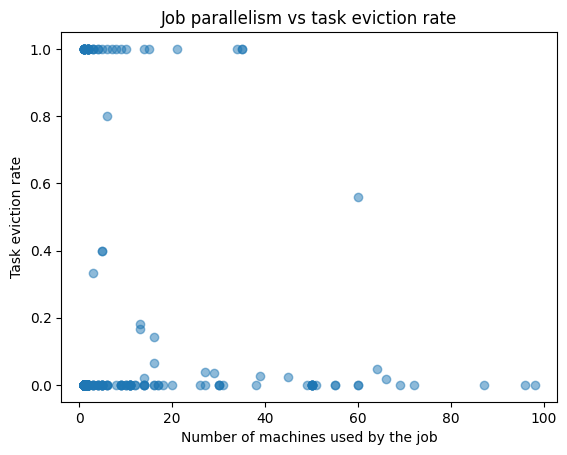

In [38]:
# Visualize correlation
pdf = job_analysis.sample(fraction=0.1).toPandas()

import matplotlib.pyplot as plt

plt.scatter(
    pdf["num_machines"],
    pdf["eviction_rate"],
    alpha=0.5
)

plt.xlabel("Number of machines used by the job")
plt.ylabel("Task eviction rate")
plt.title("Job parallelism vs task eviction rate")
plt.show()


#### Observation
To investigate whether job parallelism influences eviction behavior, we analyze the
relationship between the number of machines used by a job and its task eviction rate.
The results show no correletaion between eviction rates and job parallelism. 


## 13. Conclusion
Through this project, we analyzed multiple aspects of a large-scale cluster, including
hardware heterogeneity, maintenance behavior, scheduling policies, task locality, resource
usage, eviction mechanisms, and over-commitment strategies. The results show that the
cluster relies on conservative resource requests, controlled over-commitment, and task
evictions to balance utilization and performance. Overall, the analyses highlight the
robustness and flexibility of modern cluster scheduling strategies.

# II. Extending the work
## 0. Comparison of different solutions

### We will compare the use of Spark with the use a non-parrelel Python data analysis library Pandas on question 8 and question 4

#### Question 8

In [4]:
import time
from pyspark.sql.functions import col, avg
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Spark_Project").getOrCreate()
start_time = time.time()

# Load task_events
task_events = spark.read.csv(
    "data/clusterdata-2011-2/task_events/",
    header=False,
    inferSchema=True
).toDF(
    "time", "missing_info", "job_id", "task_index", "machine_id",
    "event_type", "user", "scheduling_class",
    "priority", "cpu_request", "memory_request", "disk_space_request", "different_machine_restrictions"
)


# Load task_usage
# Load and aggregate task usage
task_usage = spark.read.csv(
    "data/clusterdata-2011-2/task_usage/",
    header=False,
    inferSchema=True
).toDF(
    "start_time", "end_time", "job_id", "task_index",
    "machine_id", "cpu_rate", "canonical_memory_usage",
    "assigned_memory_usage", "unmapped_page_cache",
    "total_page_cache", "maximum_memory_usage",
    "disk_io_time", "local_disk_space_usage",
    "maximum_cpu_rate", "maximum_disk_io_time",
    "cycles_per_instruction", "memory_accesses_per_instruction",
    "sample_portion", "aggregation_type", "sampled_cpu_usage"
)

# Requests (scheduled tasks)
task_requests = task_events.filter(col("event_type") == 1) \
    .select("job_id", "task_index", "cpu_request") \
    .dropDuplicates(["job_id", "task_index"])

# Aggregate usage
task_usage_agg = task_usage.groupBy("job_id", "task_index") \
    .agg(
        avg("cpu_rate").alias("avg_cpu_usage")
    )

# Join
task_resources = task_requests.join(
    task_usage_agg,
    on=["job_id", "task_index"],
    how="inner"
)


spark_time = time.time() - start_time
print(f"Spark Q8 execution time: {spark_time:.3f} seconds")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/09 15:17:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Q8 execution time: 26.694 seconds


In [1]:
import pandas as pd
import time

start_time = time.time()

# Load small subsets
files = [
    "part-00160-of-00500.csv",
    "part-00161-of-00500.csv",
    "part-00162-of-00500.csv",
    "part-00163-of-00500.csv",
    "part-00164-of-00500.csv"
]

requests_pd = pd.concat(
    [
        pd.read_csv(f"data/clusterdata-2011-2/task_events/{f}", header=None)
        for f in files
    ],
    ignore_index=True
)

requests_pd.columns = [
    "time", "missing_info", "job_id", "task_index", "machine_id",
    "event_type", "user", "scheduling_class",
    "priority", "cpu_request", "memory_request",
    "disk_space_request", "different_machine_restrictions"
]

usage_pd = pd.concat(
    [
        pd.read_csv(f"data/clusterdata-2011-2/task_usage/{f}", header=None)
        for f in files
    ],
    ignore_index=True
)
usage_pd.columns = [
    "start_time", "end_time", "job_id", "task_index",
    "machine_id", "cpu_rate", "canonical_memory_usage",
    "assigned_memory_usage", "unmapped_page_cache",
    "total_page_cache", "maximum_memory_usage",
    "disk_io_time", "local_disk_space_usage",
    "maximum_cpu_rate", "maximum_disk_io_time",
    "cycles_per_instruction", "memory_accesses_per_instruction",
    "sample_portion", "aggregation_type", "sampled_cpu_usage"
]

# Filter scheduled tasks
requests_pd = requests_pd[requests_pd["event_type"] == 1]
requests_pd = requests_pd.drop_duplicates(subset=["job_id", "task_index"])

# Aggregate usage
usage_agg_pd = (
    usage_pd.groupby(["job_id", "task_index"])["cpu_rate"]
            .mean()
            .reset_index(name="avg_cpu_usage")
)

# Join
task_resources_pd = pd.merge(
    requests_pd[["job_id", "task_index", "cpu_request"]],
    usage_agg_pd,
    on=["job_id", "task_index"],
    how="inner"
)

pandas_time = time.time() - start_time
print(f"Pandas Q8 execution time: {pandas_time:.3f} seconds")


Pandas Q8 execution time: 20.783 seconds


#### Question 4

In [9]:
import time
from pyspark.sql.functions import col, countDistinct

# Start timing
start_time = time.time()

# Load task_events
task_events = spark.read.csv(
    "data/clusterdata-2011-2/task_events/",
    header=False,
    inferSchema=True
).toDF(
    "time", "missing_info", "job_id", "task_index", "machine_id",
    "event_type", "user", "scheduling_class",
    "priority", "cpu_request", "memory_request", "disk_space_request", "different_machine_restrictions"
)

jobs = task_events.filter(col("event_type") == 0)

jobs_per_class = jobs.groupBy("scheduling_class") \
    .agg(countDistinct("job_id").alias("num_jobs")) \
    .orderBy("scheduling_class")


spark_time = time.time() - start_time
print(f"Spark execution time: {spark_time:.3f} seconds")


Spark execution time: 8.766 seconds


In [10]:
import time
import pandas as pd

start_time = time.time()

# Load small subsets
files = [
    "part-00160-of-00500.csv",
    "part-00161-of-00500.csv",
    "part-00162-of-00500.csv",
    "part-00163-of-00500.csv",
    "part-00164-of-00500.csv"
]

requests_pd = pd.concat(
    [
        pd.read_csv(f"data/clusterdata-2011-2/task_events/{f}", header=None)
        for f in files
    ],
    ignore_index=True
)

requests_pd.columns = [
    "time", "missing_info", "job_id", "task_index", "machine_id",
    "event_type", "user", "scheduling_class",
    "priority", "cpu_request", "memory_request",
    "disk_space_request", "different_machine_restrictions"
]

jobs_pd = requests_pd[requests_pd["event_type"] == 0]

jobs_per_class_pd = (
    jobs_pd.groupby("scheduling_class")["job_id"]
           .nunique()
           .reset_index(name="num_jobs")
           .sort_values("scheduling_class")
)

pandas_time = time.time() - start_time
print(f"Pandas execution time: {pandas_time:.3f} seconds")


Pandas execution time: 4.507 seconds


#### Observation

As an extension, we reimplemented Question 8 (comparison between requested and actual CPU
usage) using both Apache Spark and the Pandas library. The comparison focuses on a core
operation involving aggregation of task usage data and a join with task request
information.

On a small data subset, the Pandas implementation executed faster due to its low overhead
and in-memory processing. However, this approach does not scale to the full Google Cluster
dataset because of memory limitations and the cost of large joins.

In contrast, the Spark implementation efficiently handled the same operations on larger
data volumes thanks to its distributed execution model and lazy evaluation. Although Spark
incurs higher overhead on small datasets, it is necessary for scalable processing of
large-scale cluster traces.

####